# 05 — Model 2: barrier-boost recommendation + combined result

**What the operator gets.** Every hour, a **barrier boost** value (kWh per hour; per 15 min = ÷4, the workbook unit).

**Inputs:** MB3 bottom temperature (automatic, DCS autoloader), draw and cullet (operator).

**What the data says (nb03)**
- Barrier boost is the handle for MB3: a sustained +100 kWh/h raises MB3 by about 1.9 °C over 6–12 h. Gas barely moves MB3.
- Boost is **not** an energy saver. The chosen gas model (T1/nb04) shows 1 Gcal of barrier boost replaces only about 0.67–0.70 Gcal of gas (0.81 with month fixed effects), so **less boost means less total energy**, as long as MB3 stays in band.
- In Jun–Aug 2026, MB3 ran **higher** (mean ≈ 1,321.8 °C) than its historical median (≈ 1,320.3 °C), and seeds were higher too.

**Method**
1. Fit the MB3 step response to boost from history (distributed-lag model). The early operator-feedback dip is removed (nb03).
2. **Integral controller, one step per hour:** `bb(t) = bb(t-1) + ki × (MB3_target − MB3_now) / gain`. It moves boost gradually toward whatever holds MB3 at the target.
3. **Closed-loop replay** on Jun–Aug 2026: MB3 is re-simulated as actual MB3 plus the effect of our boost changes (linear superposition).
4. Energy: less boost → the gas model (nb04) asks for more gas, with the same walk-forward frontier. The **combined** SFC is computed with both recommendations.

**Two analyses, as asked:**
- **(A) within the historical range:** boost limited to its P1–P99, MB3 targets inside the historical P5–P95.
- **(B) outside it:** no boost limits, and MB3 targets outside the historical range. This is extrapolation, shown to see the trade-off; it is not recommended without a plant trial.

In [1]:
import sys; sys.path.insert(0, '../src'); sys.path.insert(0, '../../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
import recommender as rc
q = pd.read_parquet('../data/processed/ar_15min_clean.parquet')
h = pd.read_parquet('../data/processed/hourly_clean.parquet')
d = pd.read_parquet('../data/processed/daily_clean.parquet')
u = rc.prepare_gas_features(d[d.usable]); u['E_g'] = u.energy_kcal / 1e6
TEST_START, TEST_END = '2026-06-01', '2026-08-31'
test_days = u[(u.index >= TEST_START) & (u.index <= TEST_END)].index
hh = h.loc[TEST_START:TEST_END + ' 23:00'].copy()
lim = rc.historical_limits(q, h)
BB_LIM = tuple(lim.loc['bb_kwh (per hour)', ['P1', 'P99']])
MB3_P = h.mb3_temp.quantile([0.05, 0.5, 0.95])
print('Barrier boost historical P1-P99: %.0f-%.0f kWh/h | MB3 historical P5 / median / P95: %.2f / %.2f / %.2f' % (*BB_LIM, *MB3_P))
print('Jun-Aug 2026: boost mean %.0f kWh/h, MB3 mean %.2f' % (hh.bb_kwh.mean(), hh.mb3_temp.mean()))

Barrier boost historical P1-P99: 114-610 kWh/h | MB3 historical P5 / median / P95: 1317.60 / 1320.25 / 1323.91
Jun-Aug 2026: boost mean 347 kWh/h, MB3 mean 1321.81


## 1. MB3 response to barrier boost

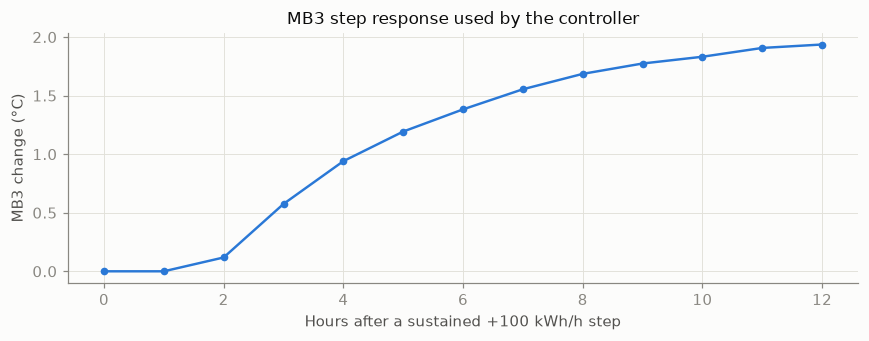

Steady-state gain: 1.94 °C per +100 kWh/h


In [2]:
step = rc.boost_step_response(h, lags=12)
GAIN = step.iloc[-1]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(step.index, step.values * 100, color=BLUE, marker='o', ms=4)
ax.set_xlabel('Hours after a sustained +100 kWh/h step'); ax.set_ylabel('MB3 change (°C)')
ax.set_title('MB3 step response used by the controller'); plt.tight_layout(); plt.show()
print('Steady-state gain: %.2f °C per +100 kWh/h' % (GAIN*100))

## 2. Choosing the controller speed
`ki` = the fraction of the needed correction applied each hour. Too high and MB3 oscillates (the furnace takes 6–12 h to respond); too low and it's slow. Tested at the historical-median target.

In [3]:
tune = []
for ki in [0.05, 0.1, 0.2, 0.3]:
    r = rc.simulate_boost_controller(hh, step, MB3_P[0.5], ki=ki, bb_limits=BB_LIM)
    tune.append(dict(ki=ki, mb3_mean=r.mb3_sim.mean(), mb3_sd=r.mb3_sim.std(), mb3_abs_err=(r.mb3_sim - MB3_P[0.5]).abs().mean(),
                     boost_mean=r.bb_rec.mean(), boost_hourly_change=r.bb_rec.diff().abs().mean()))
tune = pd.DataFrame(tune); tune.round(2)

,ki,mb3_mean,mb3_sd,mb3_abs_err,boost_mean,boost_hourly_change
0,0.05,1320.28,1.36,1.07,267.55,2.69
1,0.10,1320.29,1.39,1.09,267.62,5.43
2,0.20,1320.33,1.61,1.26,269.73,12.16
3,0.30,1320.42,1.98,1.58,274.10,21.78


**Choice: ki = 0.1.** It holds MB3 close to target with small hourly boost moves (operator friendly). Faster settings barely improve tracking but move the boost more.

## 3. Scenarios: MB3 target inside vs outside the historical range

In [4]:
KI = 0.1
scen = [('A', 'actual Jun-Aug level', hh.mb3_temp.mean(), BB_LIM),
        ('A', 'historical P75', h.mb3_temp.quantile(0.75), BB_LIM),
        ('A', 'historical median', MB3_P[0.5], BB_LIM),
        ('A', 'best-days median (nb03)', 1319.9, BB_LIM),
        ('A', 'historical P25', h.mb3_temp.quantile(0.25), BB_LIM),
        ('B', 'below historical P5', MB3_P[0.05] - 0.5, (0, np.inf)),
        ('B', 'far below (P5 - 1.5 °C)', MB3_P[0.05] - 1.5, (0, np.inf)),
        ('B', 'above historical P95 (more boost)', MB3_P[0.95] + 0.5, (0, np.inf))]
sims = {}
for grp, name, tgt_mb3, lims in scen:
    sims[name] = (grp, tgt_mb3, rc.simulate_boost_controller(hh, step, tgt_mb3, ki=KI, bb_limits=lims))
rows = []
for name, (grp, tgt_mb3, r) in sims.items():
    rows.append(dict(scenario=grp, mb3_target=name, target_C=tgt_mb3, boost_actual=r.bb_kwh.mean(), boost_rec=r.bb_rec.mean(),
                     boost_change_pct=100*(r.bb_rec.mean()/r.bb_kwh.mean()-1), mb3_sim_mean=r.mb3_sim.mean(),
                     mb3_sim_P5=r.mb3_sim.quantile(.05), mb3_sim_P95=r.mb3_sim.quantile(.95),
                     hours_outside_hist_P5_P95=100*((r.mb3_sim < MB3_P[0.05]) | (r.mb3_sim > MB3_P[0.95])).mean(),
                     boost_above_hist_P99_pct=100*(r.bb_rec > BB_LIM[1]).mean(), boost_below_hist_P1_pct=100*(r.bb_rec < BB_LIM[0]).mean()))
scen_tab = pd.DataFrame(rows); scen_tab.round(2)

,scenario,mb3_target,target_C,boost_actual,boost_rec,boost_change_pct,mb3_sim_mean,mb3_sim_P5,mb3_sim_P95,hours_outside_hist_P5_P95,boost_above_hist_P99_pct,boost_below_hist_P1_pct
0,A,actual Jun-Aug level,1321.81,347.45,347.79,0.10,1321.82,1319.41,1324.05,6.52,0.0,0.00
1,A,historical P75,1321.65,347.45,339.55,-2.27,1321.66,1319.26,1323.89,5.16,0.0,0.00
2,A,historical median,1320.25,347.45,267.62,-22.98,1320.29,1317.85,1322.54,3.62,0.0,0.00
3,A,best-days median (nb03),1319.90,347.45,250.34,-27.95,1319.96,1317.53,1322.26,5.43,0.0,0.00
4,A,historical P25,1319.22,347.45,217.32,-37.45,1319.33,1316.96,1321.71,9.92,0.0,0.00
5,B,below historical P5,1317.10,347.45,107.07,-69.18,1317.22,1314.85,1319.66,61.82,0.0,56.11
6,B,far below (P5 - 1.5 °C),1316.10,347.45,62.80,-81.92,1316.37,1314.10,1318.85,80.75,0.0,81.61
7,B,above historical P95 (more boost),1324.41,347.45,482.66,38.92,1324.40,1321.97,1326.73,64.45,4.8,0.00


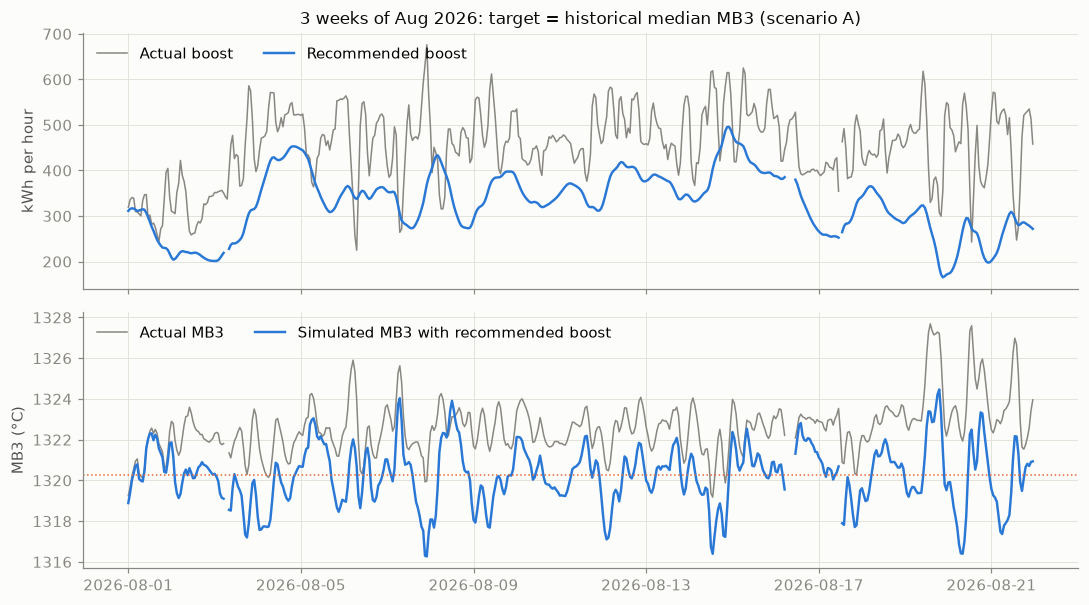

In [5]:
r = sims['historical median'][2].loc['2026-08-01':'2026-08-21']
fig, ax = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
ax[0].plot(r.index, r.bb_kwh, color=MUTED, lw=1.0, label='Actual boost')
ax[0].plot(r.index, r.bb_rec, color=BLUE, lw=1.6, label='Recommended boost'); ax[0].set_ylabel('kWh per hour'); ax[0].legend(loc='upper left', ncol=2)
ax[1].plot(r.index, r.mb3_temp, color=MUTED, lw=1.0, label='Actual MB3')
ax[1].plot(r.index, r.mb3_sim, color=BLUE, lw=1.6, label='Simulated MB3 with recommended boost')
ax[1].axhline(MB3_P[0.5], color=ORANGE, lw=1, ls=':'); ax[1].set_ylabel('MB3 (°C)'); ax[1].legend(loc='upper left', ncol=2)
ax[0].set_title('3 weeks of Aug 2026: target = historical median MB3 (scenario A)')
plt.tight_layout(); plt.show()

## 4. Combined back-test: boost (Model 2) + gas (Model 1)
For each test day:
1. Daily barrier boost = sum of the hourly recommendations (scaled to the full day).
2. The gas target is recomputed by the nb04 walk-forward frontier model **with that boost as input**, so gas rises where boost falls.
3. Combined SFC = (gas target + (recommended barrier + actual melter boost) × 860) / draw.

Also shown: a pessimistic case using the month-fixed-effects displacement (0.81 Gcal gas per Gcal boost, nb03) instead of the frontier model's own coefficient.

In [6]:
TAU, WIN = 0.25, 45
def combined(name):
    grp, tgt_mb3, r = sims[name]
    day_bb = r.bb_rec.groupby(r.index.normalize()).mean() * 24          # kWh/day
    rows = []
    for day in test_days:
        row = u.loc[day]
        bb_rec = day_bb.get(day, np.nan)
        if np.isnan(bb_rec):
            continue
        bb_g_rec = bb_rec * 860 / 1e6
        gas_tgt_actual_bb = rc.daily_gas_target(u, day)
        gas_tgt_rec_bb = rc.daily_gas_target(u, day, {'bb_g': bb_g_rec})
        gas_pess = gas_tgt_actual_bb + 0.81 * (row.bb_g - bb_g_rec)
        E_gas_only = gas_tgt_actual_bb + row.bb_g + row.mb_g
        E_comb = gas_tgt_rec_bb + bb_g_rec + row.mb_g
        E_comb_pess = gas_pess + bb_g_rec + row.mb_g
        rows.append(dict(date=day, draw_t=row.draw_t, cullet_pct=row.cullet_pct, E_act=row.E_g, E_gas_only=E_gas_only,
                         E_comb=E_comb, E_comb_pess=E_comb_pess, bb_act=row.bb_kwh, bb_rec=bb_rec))
    c = pd.DataFrame(rows).set_index('date')
    for k in ['act', 'gas_only', 'comb', 'comb_pess']:
        c[f'sfc_{k}'] = c[f'E_{k}'] * 1e6 / (c.draw_t * 1000)
    c['scenario'] = grp; c['mb3_target'] = name
    return c
comb = {name: combined(name) for name in sims}
res = pd.DataFrame({name: {'scenario': c.scenario.iloc[0],
                           'boost change %': 100*(c.bb_rec.sum()/c.bb_act.sum()-1),
                           'SFC actual': c.sfc_act.mean(),
                           'gas model only %': 100*(1-c.sfc_gas_only.mean()/c.sfc_act.mean()),
                           'gas + boost %': 100*(1-c.sfc_comb.mean()/c.sfc_act.mean()),
                           'gas + boost, pessimistic %': 100*(1-c.sfc_comb_pess.mean()/c.sfc_act.mean())}
                    for name, c in comb.items()}).T
res

,scenario,boost change %,SFC actual,gas model only %,gas + boost %,"gas + boost, pessimistic %"
actual Jun-Aug level,A,0.552168,1605.272368,0.638186,0.57882,0.609803
historical P75,A,-1.788132,1605.272368,0.638186,0.635953,0.645228
historical median,A,-22.305484,1605.272368,0.638186,1.136712,0.955691
best-days median (nb03),A,-27.312819,1605.272368,0.638186,1.258812,1.031363
historical P25,A,-36.947531,1605.272368,0.638186,1.493112,1.176546
below historical P5,B,-68.098158,1605.272368,0.638186,2.253986,1.64851
far below (P5 - 1.5 °C),B,-81.185754,1605.272368,0.638186,2.570603,1.844952
above historical P95 (more boost),B,38.736149,1605.272368,0.638186,-0.353793,0.031279


## 5. Against the targets the client accepted (per draw band and draw-adjusted)

In [7]:
base = u[u.in_baseline]
bins, labels = [45, 50, 55, 60, 65], ['45-50', '50-55', '55-60', '60-65']
band_base = base.groupby(pd.cut(base.draw_t, bins, labels=labels, include_lowest=True), observed=True).sfc.mean()
mA = smf.ols('E_g ~ draw_t + cullet_pct', base).fit()       # nb03 Model A (draw-adjusted M&V)
AIR_PCT = float(pd.read_csv(dp.PROCESSED / 'nb04_air_saving.csv', index_col=0).iloc[0, 0])   # nb04 §7 estimate (air at rolling P25)
c = comb['historical median'].copy()
c['band'] = pd.cut(c.draw_t, bins, labels=labels, include_lowest=True)
c['sfc_comb_air'] = c.sfc_comb * (1 - AIR_PCT/100)
bt = c.groupby('band', observed=True).agg(days=('sfc_act', 'size'), actual=('sfc_act', 'mean'), gas_only=('sfc_gas_only', 'mean'),
                                         gas_boost=('sfc_comb', 'mean'), gas_boost_air=('sfc_comb_air', 'mean'))
bt['baseline_band'] = band_base.reindex(bt.index); bt['target_2pct'] = bt.baseline_band * 0.98
bt['best_vs_baseline_%'] = 100*(bt.gas_boost_air/bt.baseline_band - 1)
print('Per draw band, scenario A, MB3 target = historical median:'); display(bt.round(1))
c['E_exp'] = mA.predict(c)
out = {k: 100*(c[col]/c.E_exp - 1).mean() for k, col in [('actual', 'E_act'), ('gas model', 'E_gas_only'), ('gas + boost', 'E_comb'), ('gas + boost (pessimistic)', 'E_comb_pess')]}
out['gas + boost + air'] = 100*((c.E_comb*(1-AIR_PCT/100))/c.E_exp - 1).mean()
print('Draw-adjusted energy vs baseline model (target -2.0%):'); pd.Series(out).round(2).to_frame('vs baseline %')

Per draw band, scenario A, MB3 target = historical median:


,days,actual,gas_only,gas_boost,gas_boost_air,baseline_band,target_2pct,best_vs_baseline_%
band,,,,,,,,
45-50,5,1769.9,1758.7,1766.4,1763.1,1765.9,1730.6,-0.2
50-55,18,1686.7,1685.6,1687.6,1684.4,1664.0,1630.8,1.2
55-60,33,1588.1,1575.6,1563.5,1560.7,1566.7,1535.4,-0.4
60-65,29,1545.9,1532.7,1520.4,1517.6,1521.5,1491.1,-0.3


Draw-adjusted energy vs baseline model (target -2.0%):


,vs baseline %
actual,1.14
gas model,0.48
gas + boost,-0.04
gas + boost (pessimistic),0.15
gas + boost + air,-0.23


## 6. Path to 2%

In [8]:
act = out['actual']; best = out['gas + boost + air']
bridge = pd.DataFrame([
    ['Jun-Aug 2026 actual, draw-adjusted vs baseline', round(act, 2)],
    ['Gas model (frontier + exact NCV compensation), nb04', round(out['gas model'] - act, 2)],
    ['Barrier boost to hold MB3 at historical median, nb05', round(out['gas + boost'] - out['gas model'], 2)],
    ['Air per Mcal at rolling P25 (estimate), nb04', round(best - out['gas + boost'], 2)],
    ['= Result with all data-proven levers', round(best, 2)],
    ['Target', -2.0],
    ['Remaining gap (needs trial levers / draw)', round(-2.0 - best, 2)],
], columns=['step', '% vs draw-adjusted baseline'])
bridge.to_csv('../data/processed/path_to_2pct.csv', index=False)     # read by nb03 (savings waterfall)
bridge

,step,% vs draw-adjusted baseline
0,"Jun-Aug 2026 actual, draw-adjusted vs baseline",1.14
1,"Gas model (frontier + exact NCV compensation),...",-0.65
2,Barrier boost to hold MB3 at historical median...,-0.52
3,"Air per Mcal at rolling P25 (estimate), nb04",-0.18
4,= Result with all data-proven levers,-0.23
5,Target,-2.00
6,Remaining gap (needs trial levers / draw),-1.77


## 7. Live use

In [9]:
bb_next = rc.recommend_boost(bb_ref_kwh_h=350, mb3_now=1321.8, mb3_target=round(MB3_P[0.5], 1),
                             gain_degC_per_kwh_h=GAIN, damping=KI, bb_limits=BB_LIM)
print('Example: boost now 350 kWh/h, MB3 1321.8 °C, target %.1f -> next hour %.0f kWh/h (= %.1f per 15 min, workbook unit)' % (MB3_P[0.5], bb_next, bb_next/4))

Example: boost now 350 kWh/h, MB3 1321.8 °C, target 1320.2 -> next hour 342 kWh/h (= 85.4 per 15 min, workbook unit)


## 8. Summary
- **Model 2** is an hourly integral controller on MB3, built on the MB3 step response measured from history (+1.9 °C per +100 kWh/h). Its speed (`ki = 0.1`) was chosen in a closed-loop replay.
- **Scenario A (inside historical range):** in Jun–Aug 2026 MB3 ran at 1,321.8 °C, above its historical median of 1,320.3 °C. Holding the median needs **about 23% less barrier boost** (347 → 268 kWh/h), and simulated MB3 stays inside its historical P5–P95 about 96% of the time.
- **Scenario B (outside the range):** MB3 targets below anything seen before cut boost by 70–80% and look like 2.3–2.6% savings on paper, but MB3 then sits outside its history 60–80% of the time, so quality is unknown. Raising boost above history **increases** SFC (−0.35%). Neither is recommended without a trial.
- **Combined, Jun–Aug 2026 (scenario A, MB3 at historical median):**
  - gas + boost saves **1.1%** SFC versus actual (1.0% if gas replaces boost at the pessimistic 0.81 rate)
  - with the air trim, about **1.3%**
  - draw-adjusted, this moves the furnace from **+1.14% to −0.23%** against the baseline model
  - the 55–60 t band (the most common) reaches −0.4% versus its band baseline
- **Gap to −2%:** about **1.8 points** remain. Ageing added about 1.1% since the baseline, which the data-proven levers recover, plus about 0.2% more. The rest must come from trial levers:
  - a −1 to −2 °C optical setpoint step (seed headroom: P95 = 21 against a spec of 30)
  - MB3 at the historical P25 (still inside history; 1.5% combined in §4, to be confirmed in a trial with daily seed checks)
  - higher draw / fewer line stops (+1 t/day ≈ −1% SFC)
- *Note:* this notebook uses daily gas targets without the 15-min optical trim, so its "gas model only" figure (0.64%) differs slightly from nb04 (0.75%).